In [4]:
!nvidia-smi

Fri Jun  5 10:17:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# week 1 data pipeline
galaxy zoo 2 dataset loading and preprocessing

# Install kaggle

In [5]:
!pip install kaggle

# upload kaggle API Token

In [13]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"himanshu0310sagar","key":"b3ed65dbc5968b6ae86d40e1b8c2975c"}'}

In [14]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("kaggle configured successfully!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
kaggle configured successfully!


In [15]:
!kaggle datasets list | head

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


 # week 1 data pipeline
 dataset download and preprocessing for galaxy zoo images


 # step 1 : download dataset

In [16]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:35<00:00, 92.4MB/s]



# step 2: unzip dataset

In [17]:
!unzip -q galaxy-zoo-2-images.zip

In [18]:
!ls

 galaxy-zoo-2-images.zip    images_gz2	       sample_data
 gz2_filename_mapping.csv  'kaggle (1).json'


# step 3 : inspect raw data layout

In [19]:
!ls images_gz2|head

images


In [20]:
import pandas as pd

mapping = pd.read_csv("gz2_filename_mapping.csv")
mapping.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


# step 4: download labels

In [21]:
!wget -O gz2_hart16.csv.gz https://data.galaxyzoo.org/gz2_hart16.csv.gz

--2026-06-05 10:33:47--  https://data.galaxyzoo.org/gz2_hart16.csv.gz
Resolving data.galaxyzoo.org (data.galaxyzoo.org)... 20.241.225.41
Connecting to data.galaxyzoo.org (data.galaxyzoo.org)|20.241.225.41|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://static.zooniverse.org/data.galaxyzoo.org/gz2_hart16.csv.gz [following]
--2026-06-05 10:33:48--  https://static.zooniverse.org/data.galaxyzoo.org/gz2_hart16.csv.gz
Resolving static.zooniverse.org (static.zooniverse.org)... 150.171.109.145, 2603:1061:14:90::1
Connecting to static.zooniverse.org (static.zooniverse.org)|150.171.109.145|:443... connected.
HTTP request sent, awaiting response... 404 The requested content does not exist.
2026-06-05 10:33:48 ERROR 404: The requested content does not exist..



In [22]:
import os

for root, dirs, files in os.walk("images_gz2"):
    print("Folder:", root)
    print("Files:", files[:5])
    break

Folder: images_gz2
Files: []


In [23]:
import os

print(os.listdir("images_gz2")[:20])

['images']


In [24]:
from pathlib import Path

RAW_ROOT = Path(".")
IMAGES_DIR = Path("images_gz2/images")

print("Number of images:",
      len(list(IMAGES_DIR.glob("*.jpg"))))

Number of images: 243434


In [25]:
!find /content -name "*.csv"

/content/gz2_filename_mapping.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [26]:
!find /content -iname "*hart*"

/content/gz2_hart16.csv.gz


In [27]:
!gunzip -f /content/gz2_hart16.csv.gz


gzip: /content/gz2_hart16.csv.gz: unexpected end of file


In [28]:
!find /content -iname "*hart*"

/content/gz2_hart16.csv.gz


In [29]:
!ls -lh /content/gz2_hart16.csv.gz

-rw-r--r-- 1 root root 0 Jun  5 10:33 /content/gz2_hart16.csv.gz


In [30]:
!rm -f/content/gz2_hart16.csv.gz

rm: invalid option -- '/'
Try 'rm --help' for more information.


In [31]:
!rm -f /content/gz2_hart16.csv.gz

In [32]:
!wget -O /content/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

--2026-06-05 10:34:42--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 52.216.48.89, 52.216.44.33, 54.231.224.25, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|52.216.48.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘/content/gz2_hart16.csv.gz’

/content/gz2_hart16 100%[===================>]  74.88M  36.9MB/s    in 2.0s    

2026-06-05 10:34:45 (36.9 MB/s) - ‘/content/gz2_hart16.csv.gz’ saved [78513011/78513011]



In [33]:
!ls -lh /content/gz2_hart16.csv.gz

-rw-r--r-- 1 root root 75M Sep 22  2016 /content/gz2_hart16.csv.gz


In [34]:
!gunzip -f /content/gz2_hart16.csv.gz

In [35]:
!ls -lh /content/gz2_hart16.csv

-rw-r--r-- 1 root root 357M Sep 22  2016 /content/gz2_hart16.csv


In [36]:
import pandas as pd

labels = pd.read_csv("/content/gz2_hart16.csv")

print(labels.head())
print(labels.columns)
print(labels.shape)

             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   
3  587741723357282317  186.251953  28.558598  12:25:00.47  +28:33:31.0   
4  587738410866966577  161.086395  14.084465  10:44:20.73  +14:05:04.1   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   
3  original      Sc+t                     28          218   
4  original        Er                     43          151   

   t01_smooth_or_features_a01_smooth_count  ...  \
0                                        0  ...   
1                                        1  ...   
2                                  

In [37]:
mapping = pd.read_csv("/content/gz2_filename_mapping.csv")

print(mapping.head())
print(mapping.columns)
print(mapping.shape)

                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
3  587722981741363323  original         4
4  587722981741559888  original         5
Index(['objid', 'sample', 'asset_id'], dtype='object')
(355990, 3)


In [38]:
print(labels[['dr7objid','sample']].head())

             dr7objid    sample
0  587732591714893851  original
1  588009368545984617  original
2  587732484359913515  original
3  587741723357282317  original
4  587738410866966577  original


In [39]:
print(mapping[['objid','sample']].head())

                objid    sample
0  587722981736120347  original
1  587722981736579107  original
2  587722981741363294  original
3  587722981741363323  original
4  587722981741559888  original


In [40]:
df = mapping.merge(
    labels[['dr7objid','gz2_class']],
    left_on='objid',
    right_on='dr7objid',
    how='inner'
)

print(df.shape)
print(df[['asset_id','gz2_class']].head())

(239695, 5)
   asset_id gz2_class
0         3        Sb
1         4      Sc?l
2         5        Er
3         6      Sc1t
4         7        Sb


In [41]:
print(df['gz2_class'].value_counts().head(20))

gz2_class
Ei       44038
Er       36764
Ser      14009
Sc?t     13509
Ec       10149
Sb        6932
SBc2m     5862
Sc        5776
Sb?t      5431
Sen       4450
SBc?t     4188
SBb2m     3364
Sc?m      3349
Sc2m      3326
SBc2t     3299
Sc2t      2942
SBb?t     2545
SBb       2100
SBc2l     2017
Sc3t      1960
Name: count, dtype: int64


# step 4 : create lables

group details galaxy classes into

-elliptical

 -spiral

 -sprial_barred

In [42]:
def high_level_label(gz2_class):
    if not gz2_class or gz2_class == "A":
        return None

    if gz2_class.startswith("E"):
        return "elliptical"

    if gz2_class.startswith("SB"):
        return "spiral_barred"

    if gz2_class.startswith("S"):
        return "spiral"

    return None

In [46]:
def get_label(x):
    if pd.isna(x):
        return None

    if str(x).startswith("E"):
        return "elliptical"

    elif str(x).startswith("SB"):
        return "spiral_barred"

    elif str(x).startswith("S"):
        return "spiral"

    return None

# step 5 : apply labels
create a simplified labe

In [47]:
df["label"] = df["gz2_class"].apply(get_label)

print(df["label"].value_counts())

label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64


# step 6: build image folder layout
create folder and organize images into clas

In [50]:
import os
for label in ['elliptical','spiral','spiral_barred']:
  os.makedirs(f"galaxy_data/{label}",exist_ok = True)

print("folder created")

folder created


# put image into class folders
 link images with their labels

In [51]:
small_df = df.dropna(subset=["label"]).sample(
    n=200,
    random_state=42
)

print("Selected images:", len(small_df))

Selected images: 200


In [52]:
import os

print("Images folder exists:",
      os.path.exists("images_gz2/images"))

print("Example image:",
      os.path.exists("images_gz2/images/1.jpg"))

Images folder exists: True
Example image: False


In [53]:
import os

files = os.listdir("images_gz2/images")

print("Total files:", len(files))
print("First 10 files:")
print(files[:10])

Total files: 243437
First 10 files:
['129893.jpg', '269557.jpg', '223555.jpg', '92378.jpg', '90024.jpg', '22112.jpg', '155435.jpg', '131741.jpg', '66448.jpg', '156580.jpg']


# step 8: link images to class folder
 create a small image folder dataset using 200 samples.

In [54]:
import os
import shutil

for _, row in small_df.iterrows():

    src = f"images_gz2/images/{row['asset_id']}.jpg"
    dst = f"galaxy_data/{row['label']}/{row['asset_id']}.jpg"

    if os.path.exists(src):
        shutil.copy(src, dst)

print("Done!")

Done!


In [55]:
for label in ["elliptical", "spiral", "spiral_barred"]:
    print(label, len(os.listdir(f"galaxy_data/{label}")))

elliptical 91
spiral 74
spiral_barred 35


# step 6 complete
 images successfully organized into class folders.

In [56]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder("galaxy_data")

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['elliptical', 'spiral', 'spiral_barred']
Total images: 200


# step 7 cmplt..
 image folder loaded successfullly with 3 classes and 200 images

In [64]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
dataset = ImageFolder(
    "galaxy_data",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['elliptical', 'spiral', 'spiral_barred']
Total images: 200


In [66]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


# step 8 complete
dataloader created successfully

- batch size : 32
- image shape : [16,3,64,64]
- label shape : [32]

# image grid plot

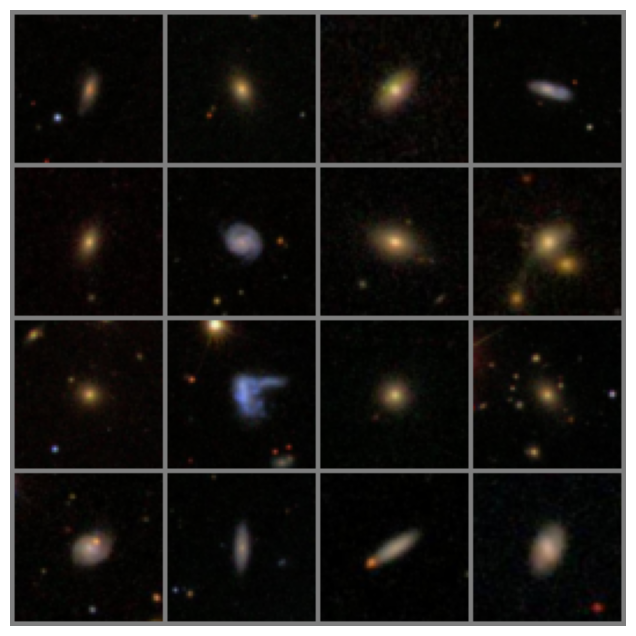

In [67]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

grid = make_grid(images[:16], nrow=4)

img = grid.permute(1, 2, 0)
img = img * 0.5 + 0.5

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [69]:
print(dataset.classes)

['elliptical', 'spiral', 'spiral_barred']


# Reflection

### 1. Most confusing part of the setup / data pipeline, and how you resolved it

The most confusing part was matching the Galaxy Zoo labels with the image files and organizing them into class folders. I resolved it by carefully merging the mapping CSV with the labels CSV and checking the outputs at each step.

### 2. Pick one galaxy class and describe what a CNN must detect to recognise it

For spiral galaxies, a CNN must detect the spiral arm structure around the central bright region. The shape and curvature of the arms help distinguish them from elliptical galaxies.

### 3. After viewing real batches, which two classes will be hardest to tell apart, and why?

Spiral and spiral_barred galaxies will be the hardest to distinguish because both contain spiral arms. The main difference is the central bar structure, which may not always be clearly visible in small or noisy images.

### 4. Why so much effort on the data pipeline before any model?

A good data pipeline ensures that images, labels, and preprocessing steps are correct before training. If the data is organized incorrectly, even a powerful model will produce poor results.